# Step 2 -- background model test

Builds the K=6 PCA basis from the last 10 frames (step 1), then wraps it in the
step-2 background model `b = mu + c @ V` with per-pixel coefficients `c` (shape
`n_pix x 6`) initialised by projecting the observed `t=13` frame. **No optimiser
runs here** -- this only checks the model, its warm start, and the autograd path
that step 3 will use.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pca_background import fit_background_basis, PCABackground
from background_model import init_background_coeffs, background

%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cpu


In [6]:
# ---- configuration --------------------------------------------------
N    = 10                # trailing snapshots that build the basis (step 1)
K    = 6                 # PCA components (decided in step 1)
T    = 13                # fit time step (same frame the cloud inversion uses)
LAM  = slice(100, 500)   # wavelength crop
YS   = slice(15, -15)    # spatial crop (y)
XS   = slice(15, -15)    # spatial crop (x)

DATA_NPZ  = '/home/milic/data/MiHI_halpha_filament/mihi_all_data.npz'


In [7]:
# ---- load the cube once; pull the basis block AND the fit frame ----
# The SAME single Iqs and lambda-crop are applied to both, so the basis and tofit
# live in identical units (the step-2 consistency requirement).
f    = np.load(DATA_NPZ, allow_pickle=True)
wav  = np.asarray(f['wav'])
cube = f['data']                                       # (t, y, x, lambda), ~5.8 GB
blk   = np.copy(cube[-N:, YS, XS, LAM]).astype(np.float32)   # last N frames -> basis
tofit = np.copy(cube[T,   YS, XS, LAM]).astype(np.float32)   # (Ny, Nx, L)   -> fit frame
del f, cube

wl        = wav[LAM]
Iqs       = float(blk[..., -20:].mean())               # pseudo-continuum, same recipe
tofit_n   = tofit / Iqs                                 # normalise fit frame by the SAME Iqs
Ny, Nx, L = tofit_n.shape
print("blk:", blk.shape, "| tofit:", tofit.shape, "| Iqs:", Iqs, "| n_pix:", Ny * Nx)

blk: (10, 116, 130, 400) | tofit: (116, 130, 400) | Iqs: 0.7617689967155457 | n_pix: 15080


In [8]:
# ---- step-1 basis (K=6) --------------------------------------------
pca = fit_background_basis(blk, n_snapshots=N, n_components=K,
                           wl_slice=None, normalization=Iqs)
print(pca)

PCABackground(L=400, K=6, M=150800, cum_var@K=0.9404)


In [9]:
# ---- step-2 background model: init coeffs from the observed data ----
tofit_pt = torch.from_numpy(tofit_n.reshape(-1, L)).to(device)     # (n_pix, L)
coeffs   = init_background_coeffs(pca, tofit_pt, device=device)     # (n_pix, K) nn.Parameter
bkg      = background(pca, coeffs)                                  # (n_pix, L)
print("coeffs:", tuple(coeffs.shape), "| background:", tuple(bkg.shape),
      "| requires_grad:", coeffs.requires_grad)

coeffs: (15080, 6) | background: (15080, 400) | requires_grad: True


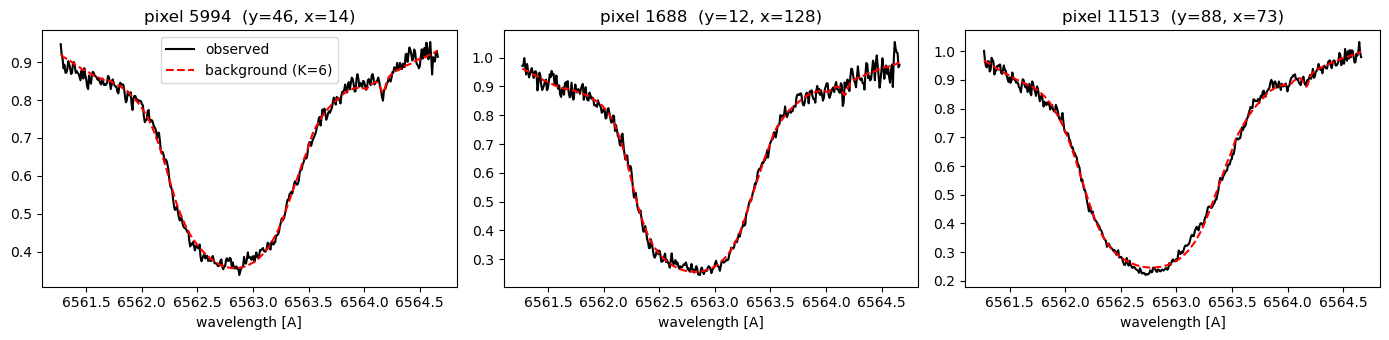

In [10]:
# ---- background vs observed for a few pixels -----------------------
np.random.seed(3)
idx    = np.random.randint(0, Ny * Nx, size=3)
bkg_np = bkg.detach().cpu().numpy()
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for j, p in enumerate(idx):
    ax[j].plot(wl, tofit_pt[p].cpu().numpy(), 'k',   label='observed')
    ax[j].plot(wl, bkg_np[p],                 'r--', label=f'background (K={K})')
    ax[j].set_title(f'pixel {p}  (y={p // Nx}, x={p % Nx})'); ax[j].set_xlabel('wavelength [A]')
ax[0].legend(); plt.tight_layout()

mean |residual| over field: 0.019755398854613304


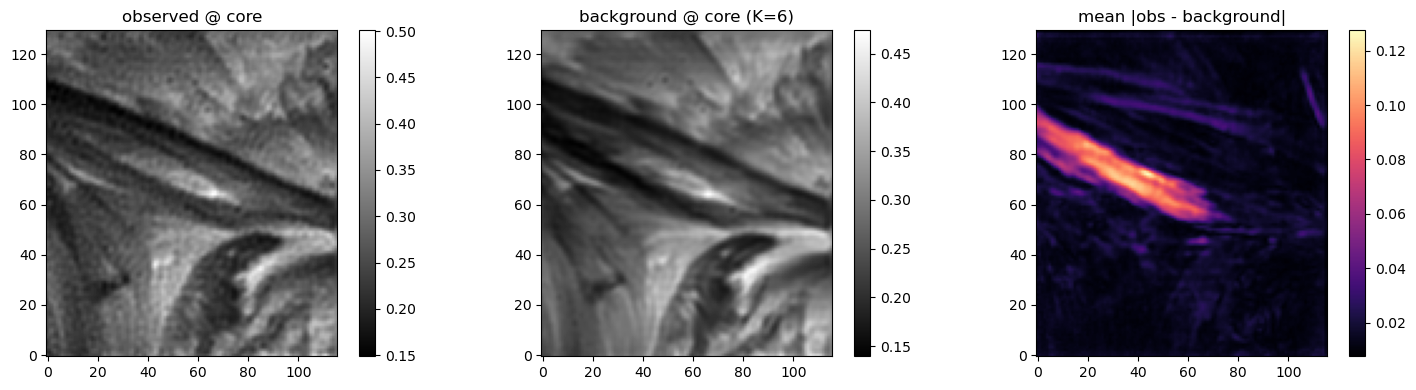

In [11]:
# ---- residual map: what the two clouds will have to explain --------
resid = (tofit_pt - bkg).detach().cpu().numpy().reshape(Ny, Nx, L)   # observed - background
core  = L // 2                                                       # near line centre
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
m0 = ax[0].imshow(tofit_n[:, :, core].T, origin='lower', cmap='gray')
m1 = ax[1].imshow(bkg_np.reshape(Ny, Nx, L)[:, :, core].T, origin='lower', cmap='gray')
m2 = ax[2].imshow(np.abs(resid).mean(axis=2).T, origin='lower', cmap='magma')
ax[0].set_title('observed @ core'); ax[1].set_title(f'background @ core (K={K})')
ax[2].set_title('mean |obs - background|')
for a, m in zip(ax, (m0, m1, m2)):
    fig.colorbar(m, ax=a, fraction=0.046)
plt.tight_layout()
print("mean |residual| over field:", float(np.abs(resid).mean()))

In [ ]:
# ---- confirm gradients flow to the coefficients (step 3 relies on this)
coeffs2 = init_background_coeffs(pca, tofit_pt, device=device)
loss = ((background(pca, coeffs2) - tofit_pt) ** 2).sum()
loss.backward()
print("coeffs.grad is not None:", coeffs2.grad is not None,
      "| grad norm:", float(coeffs2.grad.norm()),
      "| any nonzero:", bool((coeffs2.grad != 0).any()))

## Notes

- No optimiser runs here -- step 2 is *model + init only*. The residual map is
  `observed - background(project(observed))`; it should light up on the filament
  (the absorption the two clouds must explain) and stay flat on quiet Sun.
- `coeffs` is the warm start for **step 3**, where it is optimised jointly with the
  cloud parameters and (optionally) smoothed with `utils.regu2`.